# Fase 1 - Exploracion de Dataset Evaluation

## 1. Fuente y tipo de datos
- Archivo: `Evaluation.csv`
- Ubicacion: `datasets/Evaluation.csv`
- Tipo principal: Tabular (CSV)
- Componente de texto: Alto (columna `CaseSummary`)
- Clasificacion de fuente: Secundaria (dataset recolectado de una fuente externa)

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [10]:
# Carga
df = pd.read_csv('../datasets/Evaluation.csv')
df.head(3)

,Unnamed: 0,CaseSummary,Disease,Synonyms,ICD-10,ICD-11,OMIM,GARD,UMLS
0,26357,"At the time of the follow-ups, 1, 2, and 6 mon...",Waldenström macroglobulinemia,NaN,C88.0,2A85.4,153600; 610430,7872.0,C0024419
1,42784,"After transferring to our Center, the parents ...",Cystic fibrosis,CF; Mucoviscidosis,E84.0; E84.1; E84.8,CA25,219700,6233.0,C0010674
2,5807,A woman in her forties visited a local obstetr...,Neurofibromatosis type 1,Nonmosaic neurofibromatosis type 1; Von Reckli...,Q85.0,LD2D.10,162200; 162210; 613675,7866.0,C0027831


In [11]:
# 2. Caracteristicas basicas
n_rows, n_cols = df.shape
size_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f'Registros: {n_rows:,}')
print(f'Atributos: {n_cols}')
print(f'Tamano estimado en memoria: {size_mb:.2f} MB')
display(df.dtypes.to_frame('dtype'))

Registros: 6,915
Atributos: 9
Tamano estimado en memoria: 18.35 MB


,dtype
Unnamed: 0,int64
CaseSummary,str
Disease,str
Synonyms,str
ICD-10,str
ICD-11,str
OMIM,str
GARD,float64
UMLS,str


In [12]:
# Nulos y completitud
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
quality

,missing_count,missing_pct
OMIM,2378,34.39
Synonyms,2070,29.93
GARD,1503,21.74
ICD-11,697,10.08
ICD-10,680,9.83
UMLS,18,0.26
Unnamed: 0,0,0.00
CaseSummary,0,0.00
Disease,0,0.00


In [13]:
# Unicidad de identificador
id_col = 'Unnamed: 0' if 'Unnamed: 0' in df.columns else 'id'
unique_ids = df[id_col].nunique(dropna=True)
print('Columna identificadora usada:', id_col)
print('IDs unicos:', unique_ids)
print('Total filas:', len(df))
print('Hay duplicados:', unique_ids != len(df))

Columna identificadora usada: Unnamed: 0
IDs unicos: 6915
Total filas: 6915
Hay duplicados: False


In [14]:
# Resumen de columnas de interes medicas
target_cols = ['CaseSummary', 'Disease', 'Synonyms', 'ICD-10', 'ICD-11', 'OMIM', 'GARD', 'UMLS']
summary = pd.DataFrame({
    'n_unique': df[target_cols].nunique(dropna=True),
    'missing': df[target_cols].isna().sum(),
    'missing_pct': (df[target_cols].isna().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)
summary

,n_unique,missing,missing_pct
OMIM,692,2378,34.39
Synonyms,797,2070,29.93
GARD,811,1503,21.74
ICD-11,726,697,10.08
ICD-10,609,680,9.83
UMLS,1008,18,0.26
CaseSummary,6734,0,0.00
Disease,1012,0,0.00


,case_len_chars,case_len_words
count,6915.000000,6915.000000
mean,2328.567028,346.109761
std,1959.878098,289.875496
min,6.000000,2.000000
25%,863.000000,129.000000
50%,1776.000000,264.000000
75%,3345.000000,498.500000
max,44156.000000,6583.000000


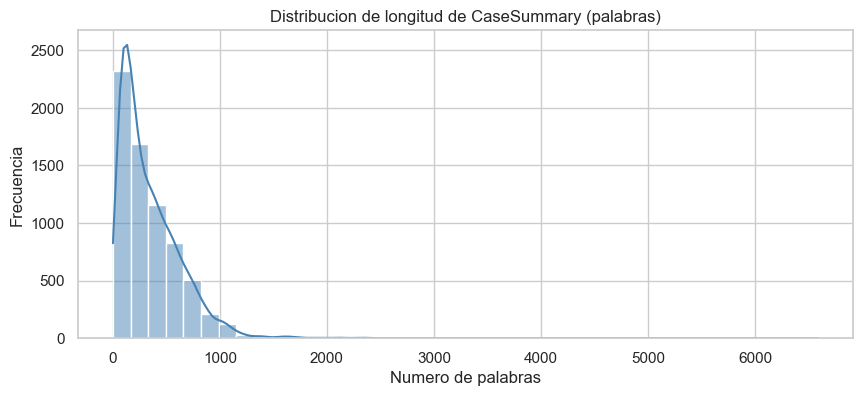

In [15]:
# Analisis de texto basico sobre CaseSummary
text_col = 'CaseSummary'
df['case_len_chars'] = df[text_col].fillna('').str.len()
df['case_len_words'] = df[text_col].fillna('').str.split().str.len()

display(df[['case_len_chars', 'case_len_words']].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df['case_len_words'], bins=40, kde=True, color='steelblue')
plt.title('Distribucion de longitud de CaseSummary (palabras)')
plt.xlabel('Numero de palabras')
plt.ylabel('Frecuencia')
plt.show()

,count
Disease,
Congenital anomaly of hepatic vein,109
Microlissencephaly,92
CACH syndrome,89
Neuroendocrine neoplasm,79
Sarcoidosis,76
Non-Hodgkin lymphoma,75
Differentiated thyroid carcinoma,66
Nodular lymphocyte predominant Hodgkin lymphoma,65
Viral hemorrhagic fever,62


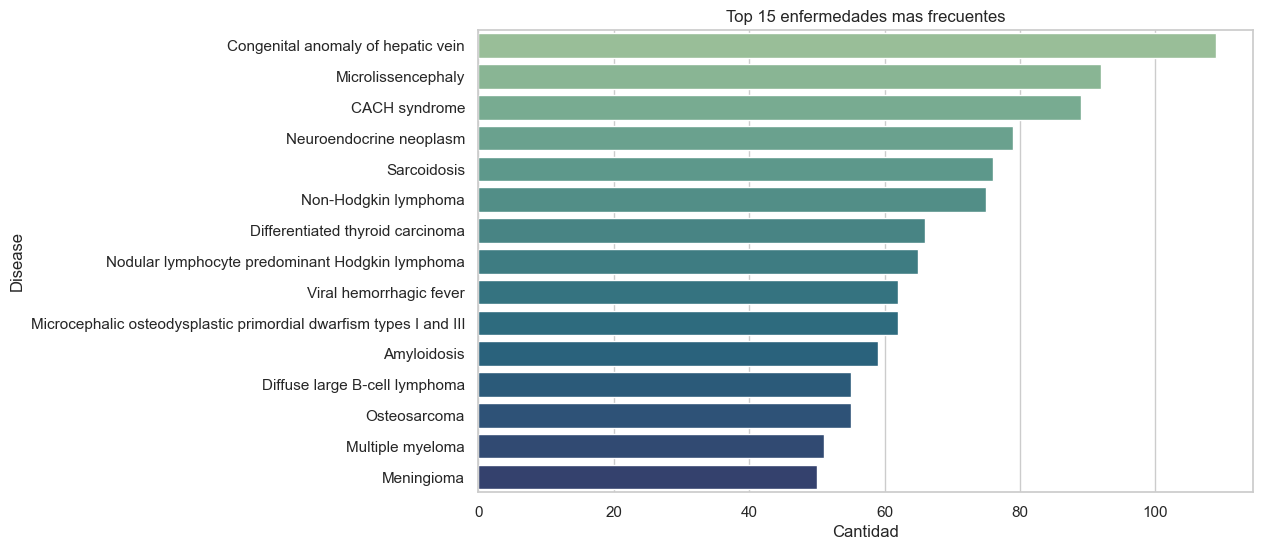

In [16]:
# Variables categoricas relevantes
top_disease = df['Disease'].value_counts().head(15)
display(top_disease.to_frame('count'))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_disease.values, y=top_disease.index, palette='crest')
plt.title('Top 15 enfermedades mas frecuentes')
plt.xlabel('Cantidad')
plt.ylabel('Disease')
plt.show()

## 3. Nivel de documentacion disponible

La estructura de columnas es clara y usa codigos medicos estandar (ICD-10, ICD-11, OMIM, UMLS),
lo que facilita interpretacion y trazabilidad. La columna `CaseSummary` contiene descripciones narrativas
de casos clinicos que permiten analisis de texto y extraccion de informacion.

## 4. Posibles aplicaciones

1. Clasificacion automatica de enfermedades a partir de texto clinico.
2. Mapeo y validacion cruzada entre nomenclaturas medicas (ICD, OMIM, UMLS).
3. Recuperacion de informacion clinica por similitud de casos.
4. Analisis de calidad de datos en codificacion medica.

## 5. Evaluacion rapida para seleccion

- Completitud: Media-Alta (depende de `Synonyms`, `GARD` y algunos identificadores faltantes).
- Relevancia: Alta para analisis clinico y tareas de NLP biomedico.
- Documentacion: Media-Alta por estandares medicos reconocidos.
- Manejabilidad: Alta (CSV tabular, facil de procesar en Python).

## Documentacion final (Fase 1)

### Hallazgos cuantitativos del analisis
- Registros: **6,915**.
- Atributos: **9**.
- Columna identificadora unica: **6,915 IDs unicos para 6,915 filas** (sin duplicados de ID).
- Nulos principales: `OMIM` (2,378), `Synonyms` (2,070), `GARD` (1,503), `ICD-11` (697), `ICD-10` (680), `UMLS` (18).
- Componente textual (`CaseSummary`): longitud media de **346.11** palabras, mediana **264**, percentil 95 **866**.
- Enfermedades mas frecuentes (ejemplos): `Congenital anomaly of hepatic vein` (109), `Microlissencephaly` (92), `CACH syndrome` (89).

### Interpretacion
- Es un dataset tabular con fuerte componente de **texto clinico**, adecuado para tareas de NLP biomedico.
- Tiene buena trazabilidad semantica por codigos estandar (`ICD-10`, `ICD-11`, `OMIM`, `UMLS`), aunque con faltantes relevantes en algunos identificadores.
- La columna `CaseSummary` tiene suficiente riqueza textual para analisis de lenguaje y extraccion de informacion.

### Cumplimiento de criterios de Fase 1 para esta base
1. **Fuente y tipo de datos**: Cumple (tabular + texto, fuente secundaria).
2. **Caracteristicas basicas**: Cumple (registros, atributos y tamano revisados).
3. **Nivel de documentacion y aplicaciones**: Cumple (estructura medica estandar y aplicaciones claras).
4. **Completitud, relevancia y manejabilidad**: Cumple (alta relevancia, con limpieza necesaria en identificadores faltantes).